In [87]:

import pandas as pd
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import r2_score, mean_squared_error, root_mean_squared_error
import sys
sys.path.append('..')
from src.feature_creation import MakeFeatures



In [88]:
features_csv = pd.read_csv('../Data/features.csv')
training_csv = pd.read_csv('../Data/train.csv')
testing_csv = pd.read_csv('../Data/test.csv')
stores_csv = pd.read_csv('../Data/stores.csv')
make_features = MakeFeatures()

In [89]:
df = make_features.merging_data(df=training_csv, features_csv=features_csv, stores_csv=stores_csv)
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df = make_features.feature_extraction(df=df)
df = df.sort_values(by=['Store', 'Dept', 'Date'], ascending=True)
df.reset_index(drop=True, inplace=True)

df['MarkDown1'] = df['MarkDown1'].fillna(0)
df['MarkDown2'] = df['MarkDown2'].fillna(0)
df['MarkDown3'] = df['MarkDown3'].fillna(0)
df['MarkDown4'] = df['MarkDown4'].fillna(0)
df['MarkDown5'] = df['MarkDown5'].fillna(0)


training_set = df[df['Date']<'2012-05-25'].copy()
validation_set = df[df['Date']>='2012-05-25'].copy()
training_set = make_features.get_time_series_features(df=training_set)

X_train = training_set.drop(columns=['Date', 'Weekly_Sales'])
y_train = training_set['Weekly_Sales']
x_val = validation_set.drop(columns=['Weekly_Sales'])
y_val = validation_set['Weekly_Sales']

#OnehotEncoding
onehotencoding_cols = ['Type', 'IsHoliday']
onehotencoding_pipeline = Pipeline(steps=[
    ("onehotencoder", OneHotEncoder(sparse_output=False))
])
#Preprocessing Pipeline
preprocessing = ColumnTransformer(transformers=[
    ('onehotencoding_pipeline', onehotencoding_pipeline, onehotencoding_cols),

], n_jobs=-1, remainder='passthrough')



In [90]:
xg_model = Pipeline(steps=[
    ("preprocessing", preprocessing),
    ("xg_model", XGBRegressor(n_jobs=-1, n_estimators=1000, max_depth=14, learning_rate=0.1))])
xg_model.fit(X_train, y_train)
print("Training completed")


Training completed


In [91]:

combined_df = pd.concat(objs=(training_set, x_val), axis=0)
combined_df = combined_df.sort_values(by=['Store', 'Dept', 'Date'])
combined_df.reset_index(drop=True, inplace=True)
combined_df

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size,Temperature,Fuel_Price,MarkDown1,...,Day,Month,Week,lag_1,lag_2,lag_4,rolling_4_mean,rolling_8_mean,rolling_4_std,rolling_8_std
0,1,1,2010-03-05,21827.90,False,A,151315,46.50,2.625,0.00,...,5,3,9,19403.54,41595.55,24924.50,32990.7700,32990.770000,12832.106391,12832.106391
1,1,1,2010-03-12,21043.39,False,A,151315,57.79,2.667,0.00,...,12,3,10,21827.90,19403.54,46039.49,32216.6200,30758.196000,13554.047185,12182.739805
2,1,1,2010-03-19,22136.64,False,A,151315,54.58,2.720,0.00,...,19,3,11,21043.39,21827.90,41595.55,25967.5950,29139.061667,10467.484020,11595.899933
3,1,1,2010-03-26,26229.21,False,A,151315,51.45,2.732,0.00,...,26,3,12,22136.64,21043.39,19403.54,21102.8675,28138.715714,1222.784968,10911.412537
4,1,1,2010-04-02,57258.43,False,A,151315,62.27,2.719,0.00,...,2,4,13,26229.21,22136.64,21827.90,22809.2850,27900.027500,2325.929203,10124.538627
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
408477,45,98,2012-09-28,NaN,False,B,118221,64.88,3.997,4556.61,...,28,9,39,NaN,NaN,NaN,NaN,NaN,NaN,NaN
408478,45,98,2012-10-05,NaN,False,B,118221,64.89,3.985,5046.74,...,5,10,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
408479,45,98,2012-10-12,NaN,False,B,118221,54.47,4.000,1956.28,...,12,10,41,NaN,NaN,NaN,NaN,NaN,NaN,NaN
408480,45,98,2012-10-19,NaN,False,B,118221,56.47,3.969,2004.02,...,19,10,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [92]:
# df_Xgb[df_Xgb['Date']=='2012-05-25']
def Test_data_forecasting(training_set, x_val, model):
    combined_df = pd.concat(objs=(training_set, x_val), axis=0)
    combined_df = combined_df.sort_values(by=['Store', 'Dept', 'Date'])
    combined_df.reset_index(drop=True, inplace=True)
    staring_date = x_val['Date'].iloc[0]
    ending_date = combined_df['Date'].iloc[-1]
    no_of_days = (ending_date - staring_date).days
    no_of_weeks = no_of_days//7
    date = staring_date
    for i in range(0, no_of_weeks+1):
        combined_df.loc[combined_df['Date']==date, 'lag_1'] =  (combined_df.groupby(['Store', 'Dept'])['Weekly_Sales']).shift(1)
        combined_df.loc[combined_df['Date']==date, 'lag_2'] =  (combined_df.groupby(['Store', 'Dept'])['Weekly_Sales']).shift(2)
        combined_df.loc[combined_df['Date']==date, 'lag_4'] =  (combined_df.groupby(['Store', 'Dept'])['Weekly_Sales']).shift(4)
        combined_df.loc[combined_df['Date']==date, 'rolling_4_mean'] =  (combined_df.groupby(['Store', 'Dept'])['Weekly_Sales']).transform(lambda x : x.shift(1).rolling(window=4, min_periods=2).mean())
        combined_df.loc[combined_df['Date']==date, 'rolling_8_mean'] =  (combined_df.groupby(['Store', 'Dept'])['Weekly_Sales']).transform(lambda x : x.shift(1).rolling(window=8, min_periods=4).mean())
        combined_df.loc[combined_df['Date']==date, 'rolling_4_std'] =  (combined_df.groupby(['Store', 'Dept'])['Weekly_Sales']).transform(lambda x : x.shift(1).rolling(window=4, min_periods=2).std())
        combined_df.loc[combined_df['Date']==date, 'rolling_8_std'] =  (combined_df.groupby(['Store', 'Dept'])['Weekly_Sales']).transform(lambda x : x.shift(1).rolling(window=8, min_periods=4).std())
        prediction = combined_df.loc[combined_df['Date']==date].copy()
        prediction = prediction.drop(columns=['Weekly_Sales', 'Date'])
        data_for_date = model.predict(prediction)
        prediction['Weekly_Sales'] = data_for_date
        combined_df.loc[combined_df['Date']==date, 'Weekly_Sales'] = data_for_date
        date = date + pd.Timedelta(days=7)
    return combined_df

In [93]:
df_Xgb = Test_data_forecasting(training_set=training_set, x_val=x_val, model=xg_model)

In [94]:

xg_mse = mean_squared_error(y_val, df_Xgb[df_Xgb['Date'] >= '2012-05-25']['Weekly_Sales'])
xg_rmse = root_mean_squared_error(y_val, df_Xgb[df_Xgb['Date'] >= '2012-05-25']['Weekly_Sales'])
xg_r2score = r2_score(y_val, df_Xgb[df_Xgb['Date'] >= '2012-05-25']['Weekly_Sales'])
print(f'The Mean squared error of the xgboost model is {xg_mse}')
print(f'The Root mean squared error of the xgboost model is {xg_rmse}')
print(f'The r2 score of the xgboost model is {xg_r2score}')



The Mean squared error of the xgboost model is 46932838.16217645
The Root mean squared error of the xgboost model is 6850.75456881769
The r2 score of the xgboost model is 0.9032821106770543


In [95]:
#-------------------LightGBM Model -------------------
light_model = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('Light_model', LGBMRegressor(n_estimators=1000, n_jobs=-1, num_leaves=70, max_depth=16, learning_rate=0.2))
])
light_model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005232 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4340
[LightGBM] [Info] Number of data points in the train set: 340460, number of used features: 27
[LightGBM] [Info] Start training from score 16062.939999


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('Light_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoding_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [96]:
df_lightgbm = Test_data_forecasting(training_set=training_set, x_val=x_val,  model=light_model)


/Users/shadow/iCloud Drive (Archive)/Documents/practice codes/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shadow/iCloud Drive (Archive)/Documents/practice codes/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shadow/iCloud Drive (Archive)/Documents/practice codes/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shadow/iCloud Drive (Archive)/Documents/practice codes/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shadow/iC

In [97]:

light_mse = mean_squared_error(y_val, df_lightgbm[df_lightgbm['Date'] >= '2012-05-25']['Weekly_Sales'])
light_rmse = root_mean_squared_error(y_val, df_lightgbm[df_lightgbm['Date'] >= '2012-05-25']['Weekly_Sales'])
light_r2score = r2_score(y_val, df_lightgbm[df_lightgbm['Date'] >= '2012-05-25']['Weekly_Sales'])
print(f'The Mean squared error of the LightGBM model is {light_mse}')
print(f'The Root mean squared error of the LightGBM model is {light_rmse}')
print(f'The r2 score of the LightGBM model is {light_r2score}')
df_lightgbm.isna().sum()

The Mean squared error of the LightGBM model is 21593718.34544234
The Root mean squared error of the LightGBM model is 4646.904167878044
The r2 score of the LightGBM model is 0.9555002650001999


Store              0
Dept               0
Date               0
Weekly_Sales       0
IsHoliday          0
Type               0
Size               0
Temperature        0
Fuel_Price         0
MarkDown1          0
MarkDown2          0
MarkDown3          0
MarkDown4          0
MarkDown5          0
CPI                0
Unemployment       0
Day                0
Month              0
Week               0
lag_1             34
lag_2             55
lag_4             89
rolling_4_mean    55
rolling_8_mean    89
rolling_4_std     55
rolling_8_std     89
dtype: int64

In [98]:
#Random Forest Model
rf_model = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('rf_model', RandomForestRegressor(n_estimators=1000, n_jobs=-1, max_depth=12, min_samples_split=2, min_samples_leaf=1))
])
rf_model.fit(X_train, y_train)
df_rf = Test_data_forecasting(training_set=training_set, x_val=x_val,model=rf_model)
rf_mse = mean_squared_error(y_val, df_rf[df_rf['Date'] >= '2012-05-25']['Weekly_Sales'])
rf_rmse = root_mean_squared_error(y_val, df_rf[df_rf['Date'] >= '2012-05-25']['Weekly_Sales'])
rf_r2score = r2_score(y_val, df_rf[df_rf['Date'] >= '2012-05-25']['Weekly_Sales'])

In [99]:
print(f'The Mean squared error of the Random Forest model is {rf_mse}')
print(f'The Root mean squared error of the Random Forest model is {rf_rmse}')
print(f'The r2 score of the Random Forest model is {rf_r2score}')

The Mean squared error of the Random Forest model is 30911098.294337496
The Root mean squared error of the Random Forest model is 5559.775021917479
The r2 score of the Random Forest model is 0.9362992671921594


In [100]:

metrics_table = pd.DataFrame({
    'Models':['XGBoost_Model', 'LightGBM_Model', 'RandomForest_Model'],
    'MSE':[xg_mse, light_mse, rf_mse],
    'RMSE':[xg_rmse, light_rmse, rf_rmse],
    'R2 Score':[xg_r2score, light_r2score, rf_r2score]
})
metrics_table

,Models,MSE,RMSE,R2 Score
0,XGBoost_Model,4.693284e+07,6850.754569,0.903282
1,LightGBM_Model,2.159372e+07,4646.904168,0.955500
2,RandomForest_Model,3.091110e+07,5559.775022,0.936299


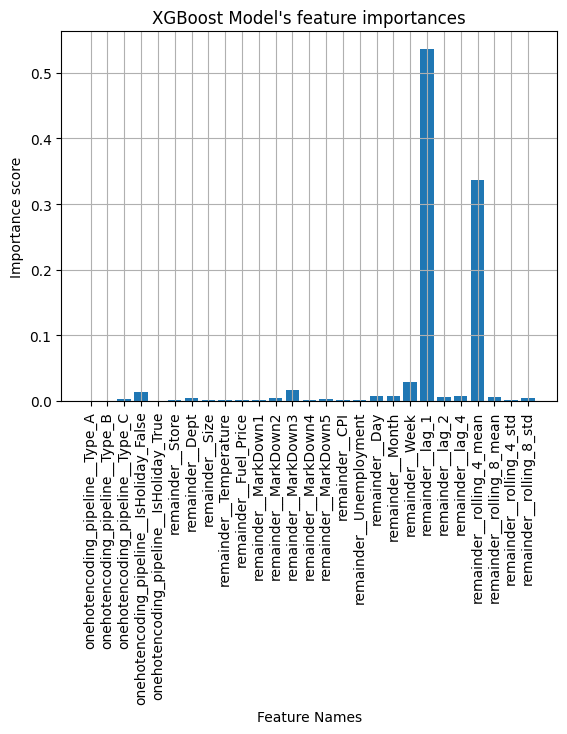

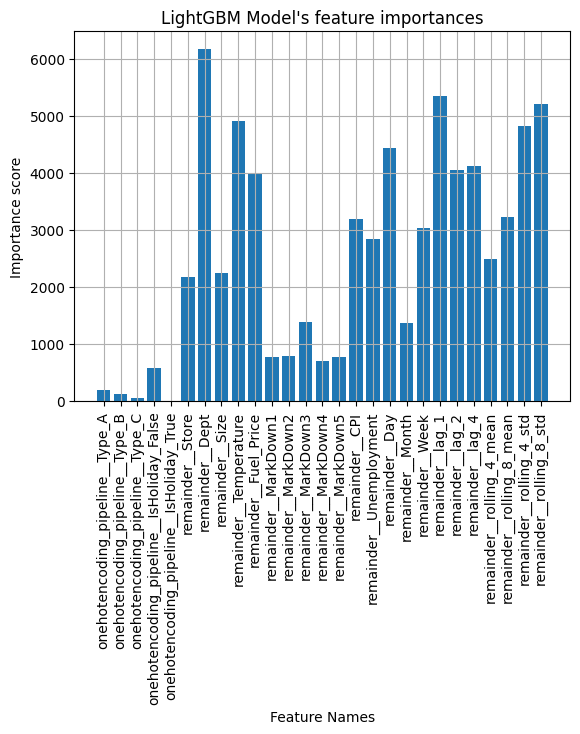

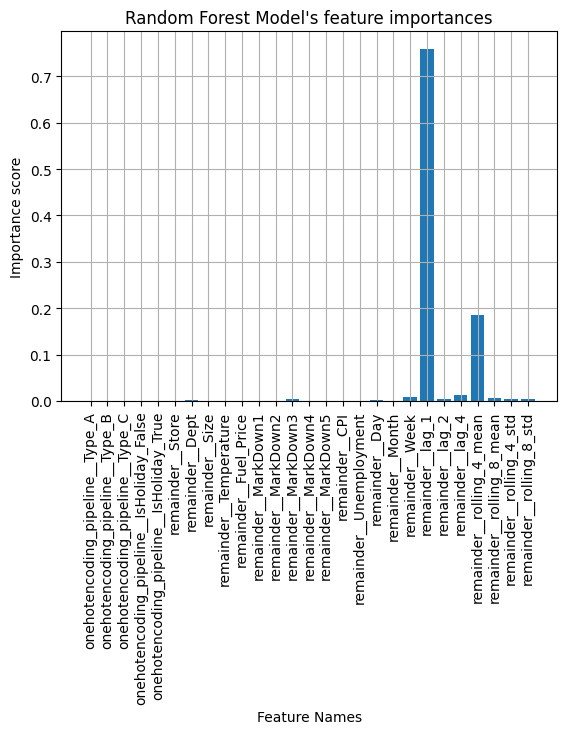

In [101]:
plt.figure()
plt.title("XGBoost Model's feature importances")
plt.bar(xg_model.named_steps['preprocessing'].get_feature_names_out(), xg_model.named_steps['xg_model'].feature_importances_)
plt.xlabel('Feature Names')
plt.ylabel('Importance score')
plt.xticks(rotation=90)
plt.grid()
plt.show()
plt.figure()
plt.title("LightGBM Model's feature importances")
plt.bar(light_model.named_steps['preprocessing'].get_feature_names_out(), light_model.named_steps['Light_model'].feature_importances_)
plt.xlabel('Feature Names')
plt.ylabel('Importance score')
plt.xticks(rotation=90)
plt.grid()
plt.show()
plt.figure()
plt.title("Random Forest Model's feature importances")
plt.bar(rf_model.named_steps['preprocessing'].get_feature_names_out(), rf_model.named_steps['rf_model'].feature_importances_)
plt.xlabel('Feature Names')
plt.ylabel('Importance score')
plt.xticks(rotation=90)
plt.grid()
plt.show()





In [104]:

full_data = make_features.get_time_series_features(df=df)
# data = Test_data_forecasting(training_set=df, x_val=full_data, model=light_model)
testing_data = make_features.merging_data(testing_csv, stores_csv=stores_csv, features_csv=features_csv)
testing_data['Date'] = pd.to_datetime(testing_csv['Date'], errors='coerce')
testing_data = make_features.feature_extraction(df=testing_data)
testing_data['MarkDown1'] = testing_data['MarkDown1'].fillna(0)
testing_data['MarkDown2'] = testing_data['MarkDown2'].fillna(0)
testing_data['MarkDown3'] = testing_data['MarkDown3'].fillna(0)
testing_data['MarkDown4'] = testing_data['MarkDown4'].fillna(0)
testing_data['MarkDown5'] = testing_data['MarkDown5'].fillna(0)
testing_data['CPI'] = testing_data['CPI'].ffill()
testing_data['Unemployment'] = testing_data['Unemployment'].ffill()
X_train_fulldata = full_data.drop(columns=['Date', 'Weekly_Sales'])
y_train_fulldata = full_data['Weekly_Sales']
light_model = Pipeline(steps=[
    ('preprocessing', preprocessing),
    ('Light_model', LGBMRegressor(n_estimators=1000, n_jobs=-1, num_leaves=70, max_depth=16, learning_rate=0.2))
])
light_model.fit(X_train_fulldata, y_train_fulldata)


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006795 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4346
[LightGBM] [Info] Number of data points in the train set: 408436, number of used features: 27
[LightGBM] [Info] Start training from score 16028.603004


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('Light_model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('onehotencoding_pipeline', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the diffe

In [105]:
overall_result = Test_data_forecasting(training_set=full_data, x_val=testing_data, model=light_model)

/Users/shadow/iCloud Drive (Archive)/Documents/practice codes/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shadow/iCloud Drive (Archive)/Documents/practice codes/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shadow/iCloud Drive (Archive)/Documents/practice codes/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shadow/iCloud Drive (Archive)/Documents/practice codes/.venv/lib/python3.13/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/Users/shadow/iC

In [106]:
overall_result.isna().sum()

Store               0
Dept                0
Date                0
Weekly_Sales        0
IsHoliday           0
Type                0
Size                0
Temperature         0
Fuel_Price          0
MarkDown1           0
MarkDown2           0
MarkDown3           0
MarkDown4           0
MarkDown5           0
CPI                 0
Unemployment        0
Day                 0
Month               0
Week                0
lag_1              41
lag_2              75
lag_4             126
rolling_4_mean     75
rolling_8_mean    126
rolling_4_std      75
rolling_8_std     126
dtype: int64